# ASLprep
## A Robust Preprocessing Pipeline for ASL Data


**Author:** Steffen Bollmann & Monika Doerig

**Date:** 17 Oct 2024

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

### Citation and Resources

#### Tools included in this workflow

__ASLPrep:__
- Adebimpe, A., Bertolero, M., Dolui, S. et al. ASLPrep: a platform for processing of arterial spin labeled MRI and quantification of regional brain perfusion. Nat Methods 19, 683–686 (2022). [https://doi.org/10.1038/s41592-022-01458-7](https://doi.org/10.1038/s41592-022-01458-7)

__FreeSurfer__:
- Dale, A.M., Fischl, B., Sereno, M.I. (1999). Cortical surface-based analysis. I. Segmentation and surface reconstruction. NeuroImage, 9(2), 179–194. [https://doi.org/10.1006/nimg.1998.0395](https://doi.org/10.1006/nimg.1998.0395)
- Fischl, B., Sereno, M.I., Dale, A.M. (1999). Cortical surface-based analysis. II: Inflation, flattening, and a surface-based coordinate system. NeuroImage, 9(2), 195–207. [https://doi.org/10.1006/nimg.1998.0396](https://doi.org/10.1006/nimg.1998.0396)
- Fischl, B. & Dale, A.M. (2000). Measuring the thickness of the human cerebral cortex from magnetic resonance images. Proceedings of the National Academy of Sciences, 97(20), 11050–11055. [https://doi.org/10.1073/pnas.200033797](https://doi.org/10.1073/pnas.200033797)   

#### Dataset
__Opensource Data from OpenNeuro:__

- Alvaro Galiano and Reyes Garcia de Eulate and Marta Vidorreta and Miriam Recio and Mario Riverol and José L. Zubieta and Maria A. Fernandez-Seara PhD (2021). Resting State Perfusion in Healthy Aging. OpenNeuro Dataset ds000240.[doi: 10.18112/openneuro.ds000240.v2.0.0](https://openneuro.org/datasets/ds000240/versions/2.0.0)

#### Educational resources
- [ASLPrep documentation](https://aslprep.readthedocs.io/en/latest/index.html)

## Introduction

Arterial Spin Labeling (ASL) MRI is a non-invasive technique for measuring cerebral blood flow (CBF) without the need for contrast agents. However, processing ASL data involves multiple complex steps — motion correction, registration to anatomical images, partial volume correction, and CBF quantification — each requiring careful parameter choices and quality control.

[ASLPrep](https://aslprep.readthedocs.io/) is an ASL preprocessing and CBF computation pipeline designed to be robust to variations in scan acquisition protocols while requiring minimal user input. It adapts its preprocessing steps depending on the input dataset and uses a combination of tools from well-known software packages (FSL, ANTs, FreeSurfer, and AFNI), selecting the best available implementation for each step. ASLPrep is largely based on [fMRIPrep](https://fmriprep.org/) and is part of the [NiPreps](https://www.nipreps.org/) community, but accounts for key differences between ASL and fMRI —for example, separate motion correction per volume type, slice-timing–aware CBF calculation instead of slice timing correction, and reference image selection based on highest-contrast volume type.                                                                    
This notebook demonstrates how to run ASLPrep on a publicly available dataset using Neurodesk, making quantitative perfusion imaging accessible without manual installation of the required dependencies.    

![image](https://raw.githubusercontent.com/PennLINC/aslprep/main/docs/_static/aslprepworkflow.png)

## Learning Objectives

By the end of this notebook, you will be able to:                                                                                                           
1. Set up and run ASLPrep on a BIDS-formatted ASL dataset using Neurodesk
2. Navigate and interpret ASLPrep's visual quality control outputs, including brain segmentation, spatial normalisation, ASL-to-T1w registration, and CBF maps
3. Identify common issues in ASL processing from the visual reports (carpet plots, registration overlays)

## Load software tools

In [1]:
# load aslprep
import module
import os
await module.load('aslprep/0.7.5')
await module.list()

['aslprep/0.7.5']

## Set up FreeSurfer license

In [ ]:
# Request a freesurfer license and store it in your homedirectory. 
# This is just an example - please replace with your license id:
license_path = os.path.expanduser("~/.license")

# Create the license file using Python (more reliable than ! commands in batch execution)
license_content = """Steffen.Bollmann@cai.uq.edu.au
21029
*Cqyn12sqTCxo
FSxgcvGkNR59Y
"""

with open(license_path, 'w') as f:
    f.write(license_content)

# Verify the license file was created
if os.path.exists(license_path):
    print(f"✅ FreeSurfer license file created at: {license_path}")
    with open(license_path, 'r') as f:
        print(f"   Lines: {len(f.readlines())}")
else:
    raise RuntimeError(f"❌ Failed to create FreeSurfer license file at {license_path}")

## Download data using DataLad

In [2]:
!datalad install https://github.com/OpenNeuroDatasets/ds000240.git
!cd ds000240 && datalad get sub-01

Cloning:   0%|                             | 0.00/2.00 [00:00<?, ? candidates/s]
Enumerating: 0.00 Objects [00:00, ? Objects/s]
                                              
Counting:   0%|                              | 0.00/1.20k [00:00<?, ? Objects/s]
                                                                                
Compressing:   0%|                             | 0.00/883 [00:00<?, ? Objects/s]
                                                                                
Receiving:   0%|                             | 0.00/2.39k [00:00<?, ? Objects/s]
                                                                                
Resolving:   0%|                                | 0.00/256 [00:00<?, ? Deltas/s]
[INFO   ] Remote origin not usable by git-annex; setting annex-ignore           
[INFO   ] https://github.com/OpenNeuroDatasets/ds000240.git/config download failed: Not Found 
[INFO   ] access to 1 dataset sibling s3-PRIVATE not auto-enabled, enable with:
| 

## Run ASLPrep                                                                                                             
The next cell runs ASLPrep on one participant from the ds000240 dataset and writes outputs to `aslprep-output/`.                                                     
A few practical notes:                              
- the FreeSurfer license file should exist at `~/.license` (created above)              
- we skip BIDS validation because this dataset is known to be BIDS-compatible, and because the validator is not yet included in the ASLPrep container                                     
- this command will likely take **a few of hours** to run                      
- if you are wondering whether it is still running, go back to the **Terminal** and type `top`               
- ASLPrep handles the full pipeline: anatomical preprocessing (brain extraction, segmentation, surface reconstruction, spatial normalisation), ASL preprocessing (motion correction, distortion correction, ASL-to-T1w registration), and CBF quantification

In [6]:
%%bash                                                                                                                                    
set -u -o pipefail

# Ensure the FreeSurfer output folder and subjects directory exists
mkdir -p "${APPTAINERENV_SUBJECTS_DIR:-$HOME/freesurfer-subjects-dir}"
mkdir -p freesurfer-output                                                                                             

aslprep ds000240 \
    aslprep-output \
    participant \
    --participant-label 01 \
    --fs-license-file ~/.license \
    --skip-bids-validation \
    -w aslprep-work \
    2>&1 | tee aslprep.log                                                                                                                                                                                                                                                                    

# Verify aslprep produced expected outputs
if [ ! -f "aslprep-output/sub-01.html" ]; then                                                                                                              
  echo "ERROR: ASLPrep did not produce the expected report (sub-01.html)"                                                                                 
  exit 1                                                                                                                                                  
fi

260413-05:05:44,704 nipype.workflow IMPORTANT:
	 Running ASLPrep version 0.7.5

         License NOTICE ##################################################
         ASLPrep 0.7.5
         Copyright 2023 The PennLINC Team and the NiPreps Developers.
         
         This product is primarily developed by the PennLINC team,
         but it is also a part of the NiPreps community.
         
         This product includes software developed by
         the NiPreps Community (https://nipreps.org/).
         
         Portions of this software were developed at the Department of
         Psychology at Stanford University, Stanford, CA, US.
         
         This software is also distributed as a Docker container image.
         The bootstrapping file for the image ("Dockerfile") is licensed
         under the MIT License.
         
         This software may be distributed through an add-on package called
         "Docker Wrapper" that is under the BSD 3-clause License.
         ##########

## ASLPrep Results

The full result report is in `aslprep-output/sub-01.html` and you can open this webpage in Jupyterlab or in the browser. Here a few items from the report as an example and for a quick checking:

### Brain mask and brain tissue segmentation of the T1w
This panel shows the template T1-weighted image (if several T1w images were found), with contours delineating the detected brain mask and brain tissue segmentations.

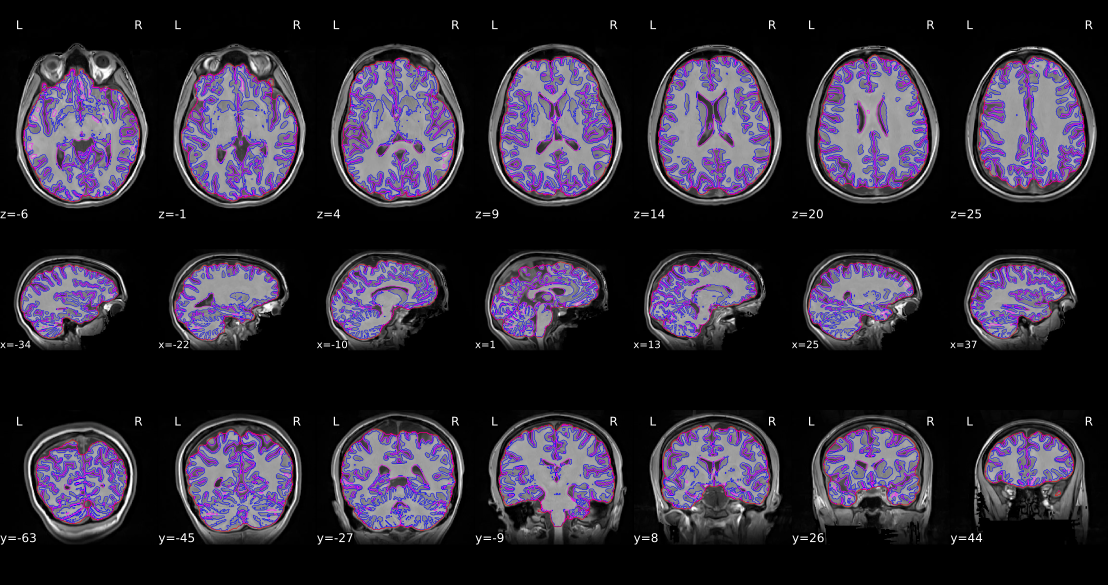

In [7]:
from IPython.core.display import SVG
SVG(filename='aslprep-output/sub-01/figures/sub-01_dseg.svg')

### Spatial normalization of the anatomical T1w reference

Results of nonlinear alignment of the T1w reference one or more template space(s)

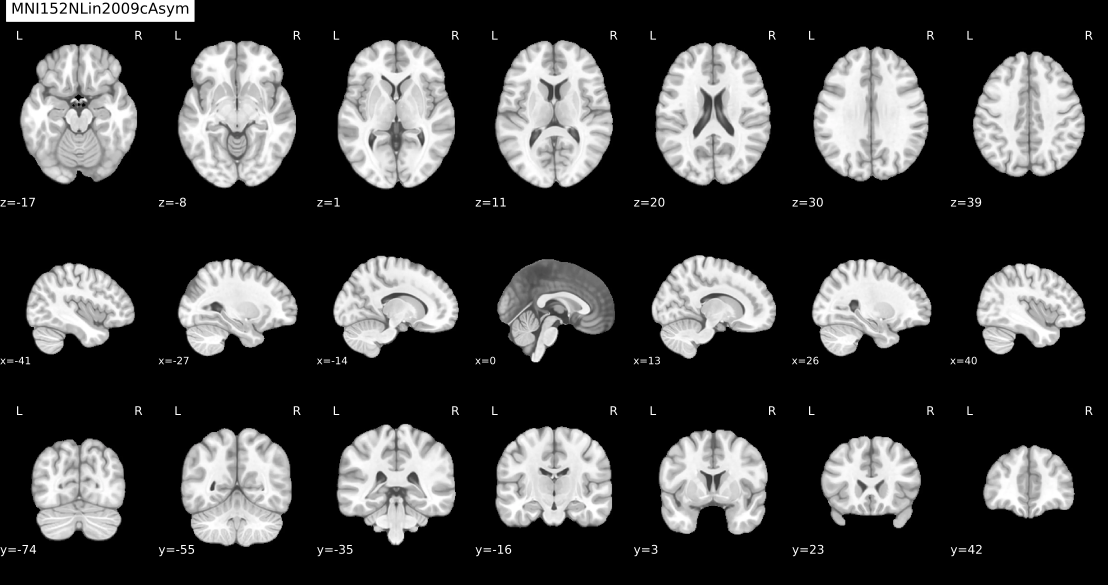

In [8]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_space-MNI152NLin2009cAsym_T1w.svg')

### Surface reconstruction
Surfaces (white and pial) reconstructed with FreeSurfer (recon-all) overlaid on the participant's T1w template.

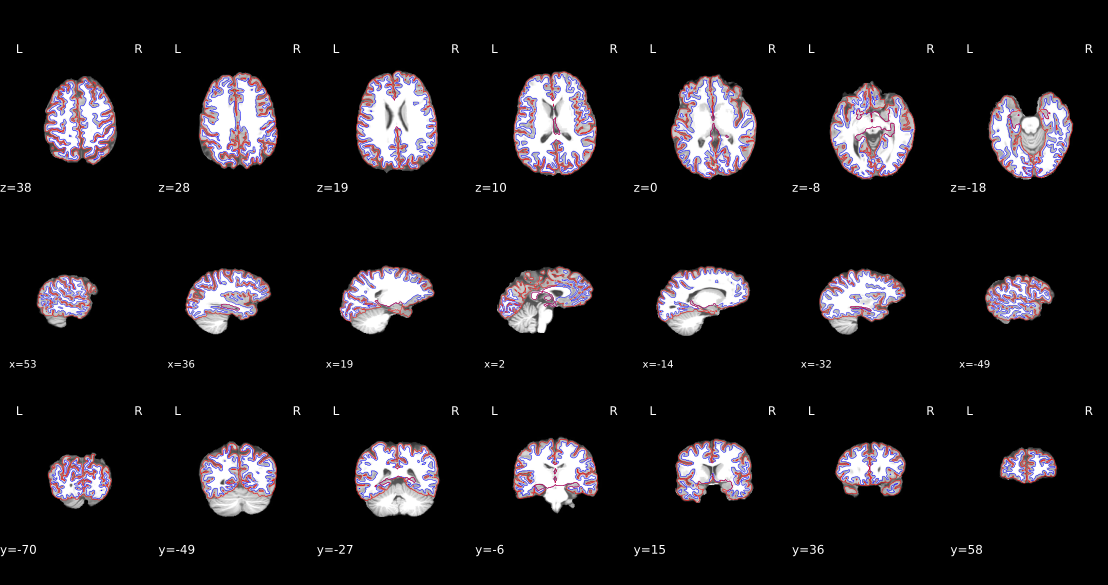

In [9]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-reconall_T1w.svg')

## Alignment of functional and anatomical MRI data (volume based)
mri_coreg (FreeSurfer) was used to generate transformations from EPI space to T1 Space - bbregister refinement rejected. Note that Nearest Neighbor interpolation is used in the reportlets in order to highlight potential spin-history and other artifacts, whereas final images are resampled using Lanczos interpolation.

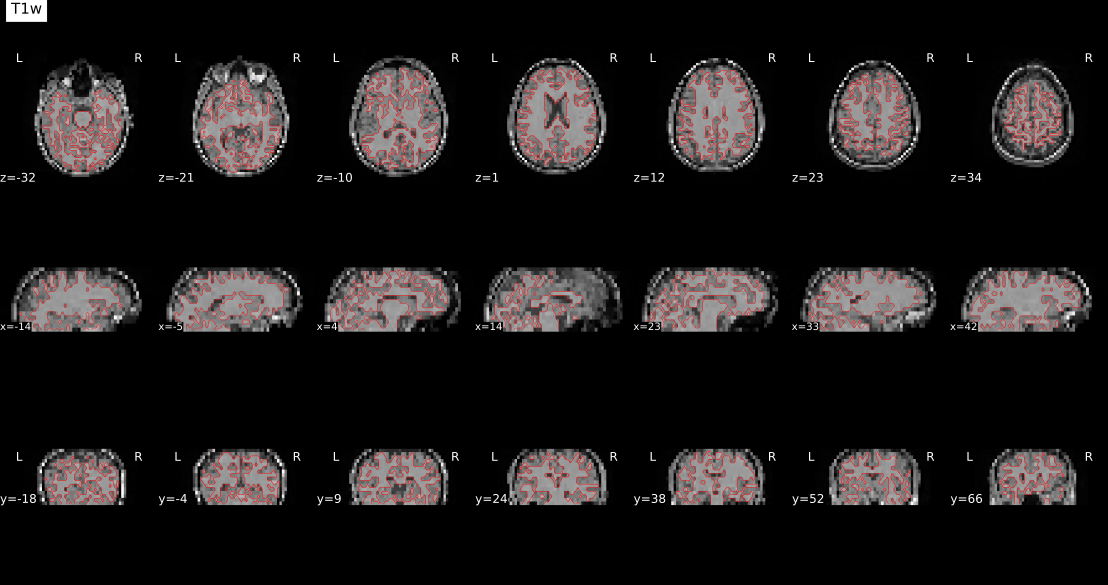

In [10]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-coreg_asl.svg')

### ASL Summary
Summary statistics are plotted, which may reveal trends or artifacts in the ASL data. DVARS and FD show the standardized DVARS and framewise-displacement measures for each time point. A carpet plot shows the time series for all voxels within the brain mask. Voxels are grouped into cortical (blue), and subcortical (orange) gray matter, cerebellum (green) and white matter and CSF (red), indicated by the color map on the left-hand side.

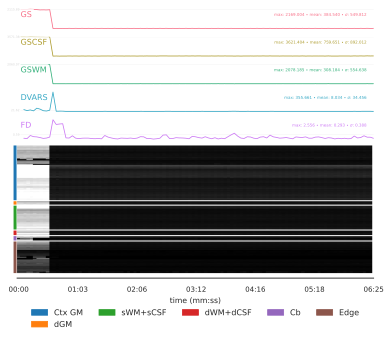

In [11]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-carpetplot_asl.svg')

### CBF
The maps plot cerebral blood flow (CBF) for basic CBF. The unit is mL/100 g/min.

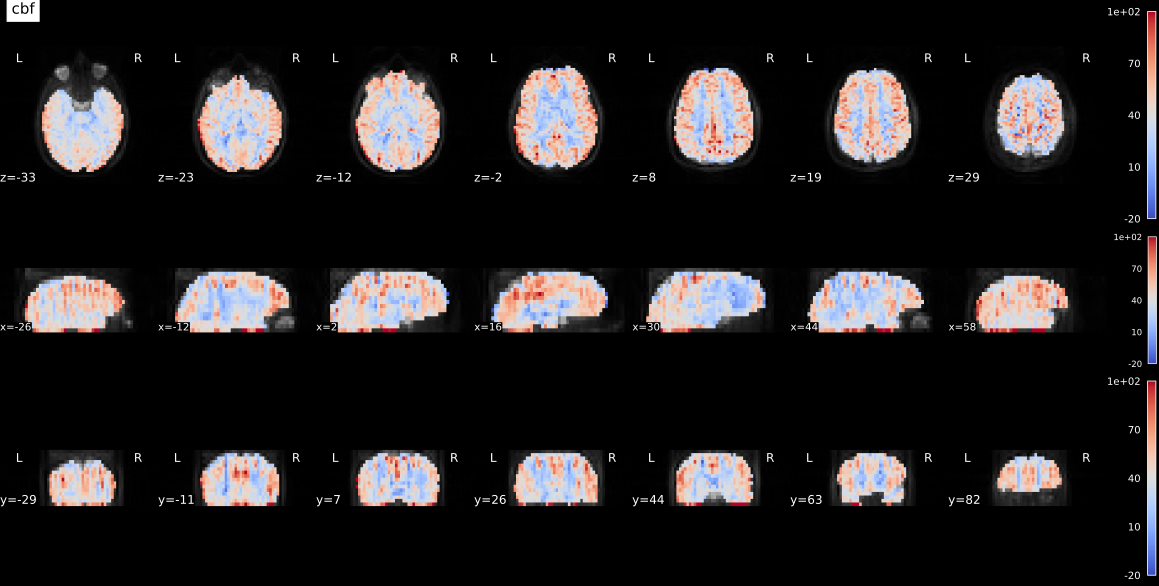

In [12]:
SVG(filename='aslprep-output/sub-01/figures/sub-01_desc-cbf_cbf.svg')

#### Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [13]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-04-13T09:55:02.039917+00:00

Python implementation: CPython
Python version       : 3.13.11
IPython version      : 9.9.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-173-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 30
Architecture: 64bit

IPython: 9.9.0

Neurodesktop version: 2026-03-27
